In [10]:
import numpy as np, itertools
import tools21cm as t2c, numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy import special
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import jn
from scipy.special import jv
from scipy.integrate import quad

from tqdm import tqdm
from ipywidgets import interact

import astropy.units as u
import astropy.constants as cst
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import Angle

from matplotlib.colors import LogNorm

In [11]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,513,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    
    return gf_data.squeeze(), l_cb

def telescope_beam_pattern(x, y, D=45, z=7):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))

def gaussian_source_2d(x, y, cov):
    """
    Calculate the value of a 2D Gaussian source at given coordinates (x, y).

    Parameters:
    - x (float): x-coordinate of the point.
    - y (float): y-coordinate of the point.
    - cov (list): Covariance matrix in arcseconds.

    Returns:
    - float: Value of the 2D Gaussian source at the given coordinates.

    Notes:
    - The covariance matrix takes two values provided in arcseconds.
    - The mean of the Gaussian source is assumed to be (0, 0).
    """
    mean = np.array([0, 0])  # Mean of the Gaussian source
    cov = np.array([[(cov[0] * u.arcsec).to('rad').value, 0], [0, (cov[1] * u.arcsec).to('rad').value]])
    x_diff = x - mean[0]
    y_diff = y - mean[1]
    inv_cov = np.linalg.inv(cov)
    exponent = -0.5 * (x_diff**2 * inv_cov[0, 0] + y_diff**2 * inv_cov[1, 1] + 2 * x_diff * y_diff * inv_cov[0, 1])
    prefactor = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)

def hirax_layout(N_ant, range):
    """
    Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x= np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y= np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)

def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def median_index(list):
    """
    Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.mean(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index

def arbitrary_index(list, value):
    """
    Find the index of the closest element in a list to a given value.

    Parameters:
    list (array-like): The list of values.
    value (float): The value to find the closest index to.

    Returns:
    int: The index of the closest element in the list to the given value.
    """
    closest_index = np.abs(list - value).argmin()
    return closest_index

def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """
    Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant= len(xyz_coord) #Number of antennas
    N_B= int(N_ant*(N_ant-1) / 2) #Number of baselines
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas

    baseline_coord= np.empty((N_B, xyz_coord.shape[1])) #Initialize a baseline vectors array
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]

        #Calculate distance between antennas
        uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
        baseline_coord[i]= uv

        #Calculate the fringe pattern
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))

        #Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        #Calculate visibility for the current baseline
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i]= visibility

        #Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility) #Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord

def visibility_rotation_synthesis(lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant):
    N_B= int(N_ant*(N_ant-1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= rotated_baselines[i]
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i]= visibility

        visibility_matrix[aa, bb]=visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix

def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to('rad').value, delta.to('rad').value
    
    return np.array([[np.sin(HA), np.cos(HA)], 
                     [-np.sin(delta)*np.cos(HA), np.sin(delta)*np.sin(HA)]])

def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """
    Computes visibility correlation and baseline distances from a given baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices= np.linspace(0, N_B-1, N_B)
    indices_combinations= list(itertools.product([index], range(N_B))) #Generate combinations
    baseline_distances= np.empty((len(indices), 2)) #Create empty array for calculating distance between two vectors
    vis_corr= np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i]= visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i]= baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm

def visibility_matrix_func_new_method(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    l_coord, m_coord= np.meshgrid(sky_coord, sky_coord)
    N_ant= len(xyz_coord)
    N_B= int(N_ant*(N_ant-1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list= np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]
        uv= (xyz_coord[bb]- xyz_coord[aa]) / lam
        baseline_coord[i]= uv
        fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis= np.sum(fringe*I_sky*beam_pattern)
        visibility_list[i]= vis
        visibility_matrix[aa, bb]= vis
        visibility_matrix[bb, aa]= np.conj(vis)
    
    return visibility_list, visibility_matrix, baseline_coord

def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin= np.linspace(u_min, u_max, int(bin_len/ bin_res))
    
    uv_plane_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='sum', bins=[uv_bin, uv_bin]).statistic
    uv_sampl_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='count', bins=[uv_bin, uv_bin]).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x= np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x

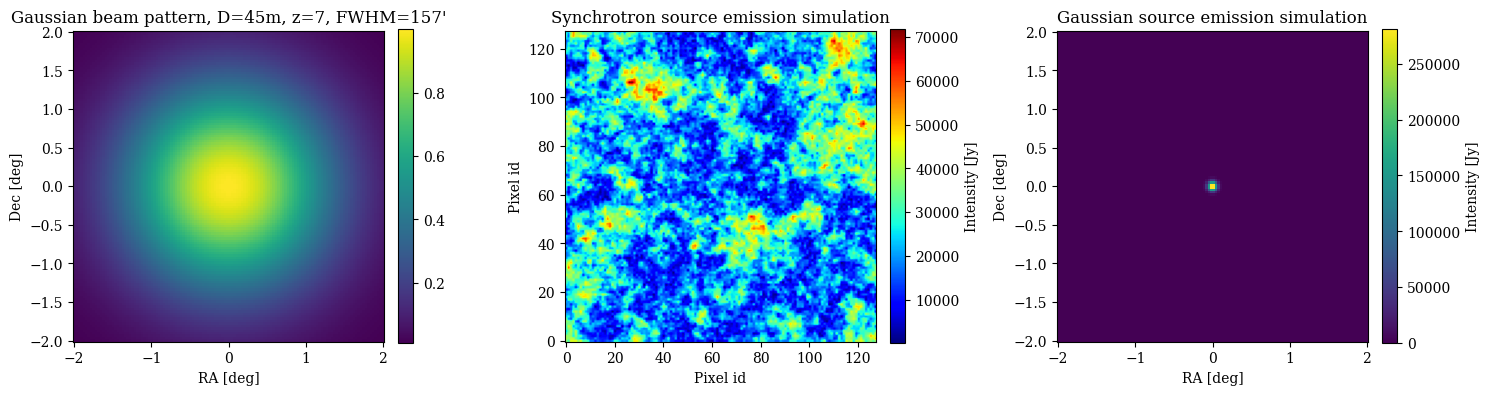

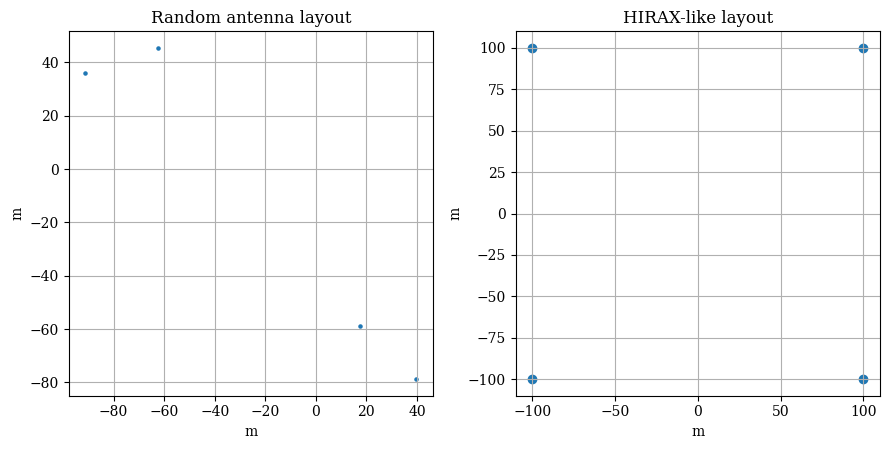

In [12]:
FoV= 4.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 128).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
#Generate the coordinates of the telescope layout
xyz_grid= hirax_layout(2**2, [-100., 100.])
xyz_random= random_layout(2**2, [-100, 100], 2024)
#***********************************************

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
ang_dim_dist= FoV.to('rad').value * cosmo.angular_diameter_distance(rshift).value

#Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, rseed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord)

#***********************************************
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[0].set_ylabel('Dec [deg]')
axes[0].set_xlabel('RA [deg]')
axes[0].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[0].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

im1 = axes[1].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[1].set_title("Synchrotron source emission simulation")
axes[1].set_ylabel('Pixel id')
axes[1].set_xlabel('Pixel id')
axes[1].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

im2 = axes[2].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axes[2].set_title('Gaussian source emission simulation')
axes[2].set_ylabel('Dec [deg]')
axes[2].set_xlabel('RA [deg]')
axes[2].set_box_aspect(1)
plt.colorbar(im2, label='Intensity [Jy]', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

#***********************************************
fig, axes= plt.subplots(1, 2, figsize=(9, 7))

axes[0].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[0].set_xlabel("m")
axes[0].set_ylabel("m")
axes[0].set_title("Random antenna layout")
axes[0].grid()
axes[0].set_box_aspect(1)

axes[1].scatter(xyz_grid[:,0], xyz_grid[:, 1])
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("HIRAX-like layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()

## __Plotting the fringe pattern using the new method.__

100%|██████████| 6/6 [00:00<00:00, 193.39it/s]


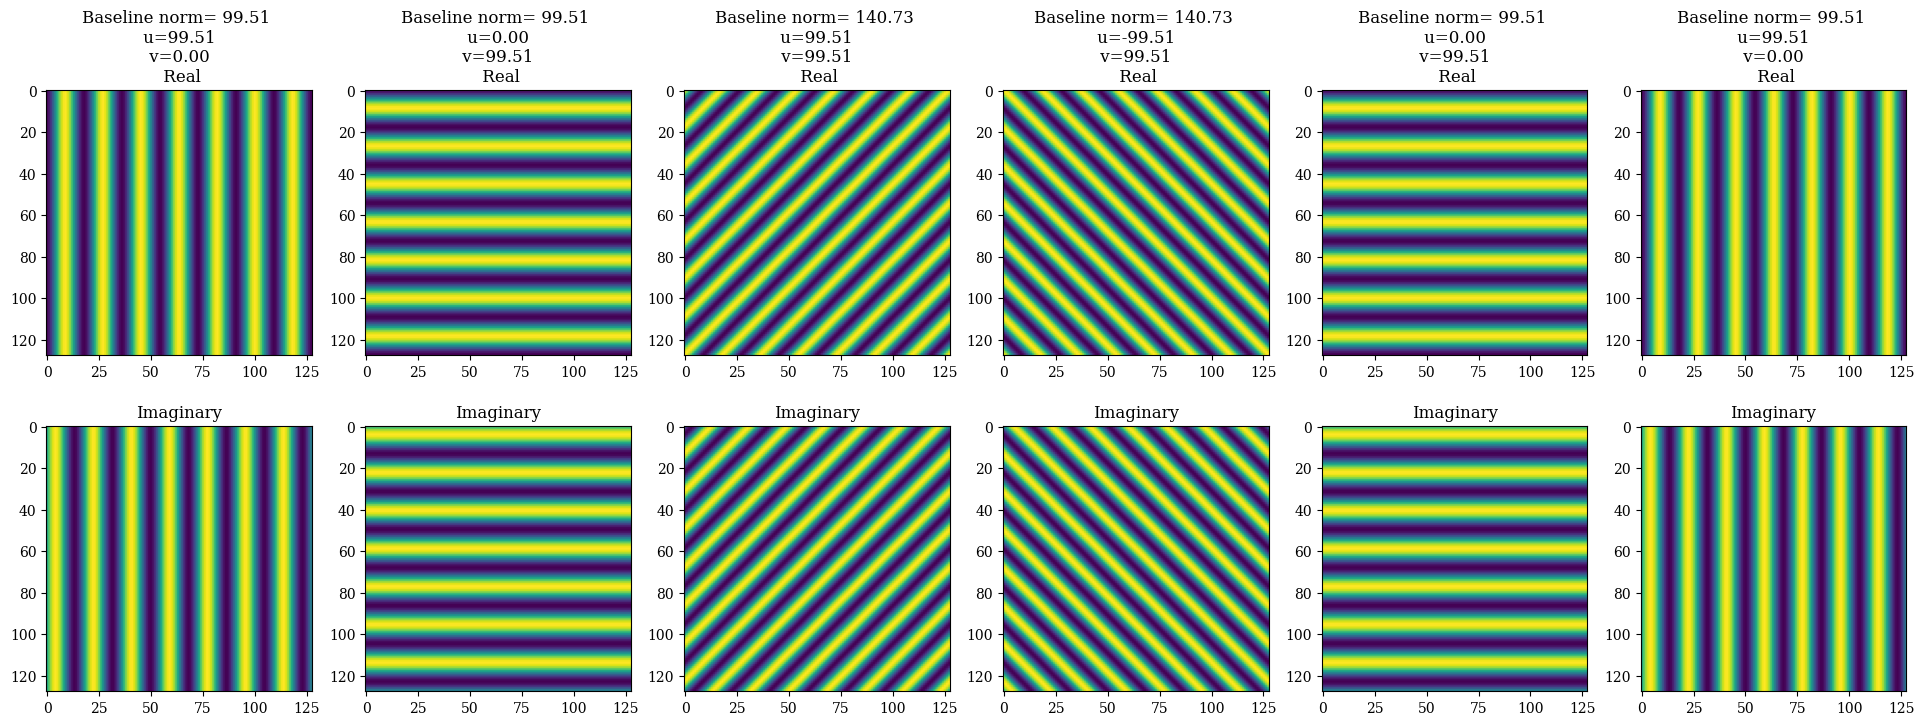

In [13]:
FoV= 4.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 128).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

xyz_coord= xyz_grid

N_ant= len(xyz_coord)
N_B= int(N_ant*(N_ant-1) / 2)
freq = t2c.cosmo.z_to_nu(rshift) * 10**6
lam = cst.c.value / freq
pair_comb= list(itertools.combinations(range(N_ant), 2))

baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
visibility_list= np.empty(N_B, dtype=np.complex128)
fringe_list= []

fig, axes= plt.subplots(2, N_B, figsize=(24, 8))

for i in tqdm(range(N_B)):
    aa, bb= pair_comb[i]

    #Calculate distance between antennas
    uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
    baseline_coord[i]= uv
    fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
    fringe_list.append(fringe)

    axes[0,i].imshow(fringe_list[i].real, cmap='viridis')
    axes[0,i].set_box_aspect(1)
    axes[0,i].set_title(f"Baseline norm= {np.linalg.norm(uv):.2f} \n u={baseline_coord[i][0]:.2f} \n v={baseline_coord[i][1]:.2f} \n Real")
    axes[1,i].imshow(fringe_list[i].imag, cmap='viridis')
    axes[1,i].set_title("Imaginary")
    axes[1,i].set_box_aspect(1)

## __Testing to see if there is any difference between the two methods (there is none).__

100%|██████████| 6/6 [00:00<00:00, 260.64it/s]


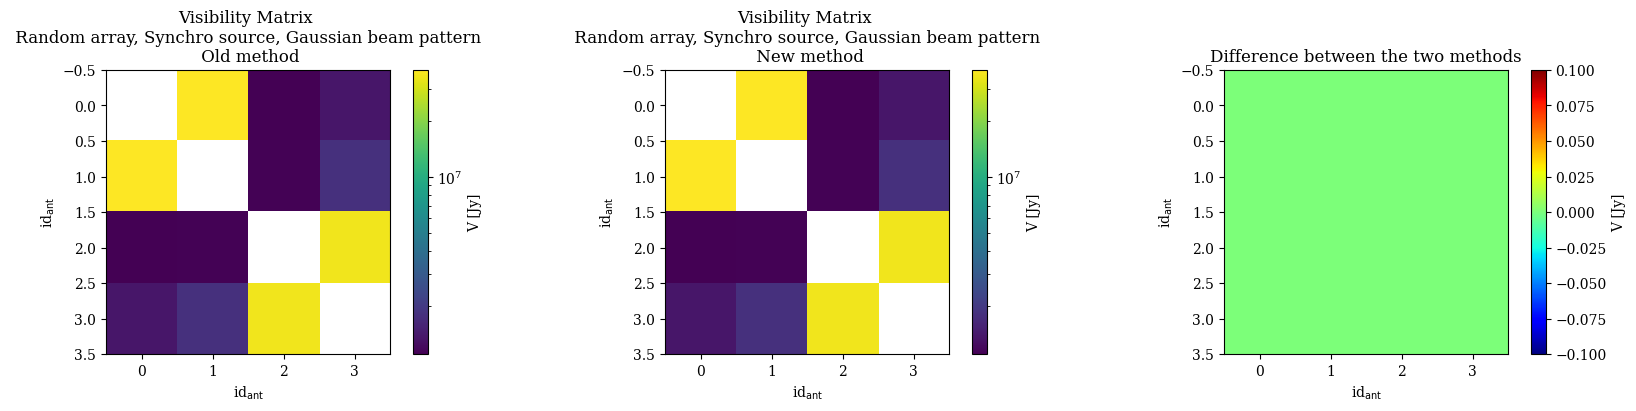

In [14]:
fig, axes= plt.subplots(1, 3, figsize=(17, 4), constrained_layout= True)

visls_random1, vismx_random1, bl_random1= visibility_matrix_func(xyz_random, lmn_coord, rshift, synchro_source, beam_pattern)
visls_random2, vismx_random2, bl_random2= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, beam_pattern)

im0= axes[0].imshow(np.abs(vismx_random1), cmap='viridis', norm=LogNorm())
axes[0].set_xlabel(r'id$_\mathrm{ant}$')
axes[0].set_ylabel(r'id$_\mathrm{ant}$')
axes[0].set_title('Visibility Matrix \n Random array, Synchro source, Gaussian beam pattern \n Old method')
axes[0].set_box_aspect(1)
plt.colorbar(im0, ax=axes[0], label='V [Jy]')

im1= axes[1].imshow(np.abs(vismx_random2), cmap='viridis', norm=LogNorm())
axes[1].set_xlabel(r'id$_\mathrm{ant}$')
axes[1].set_ylabel(r'id$_\mathrm{ant}$')
axes[1].set_title('Visibility Matrix \n Random array, Synchro source, Gaussian beam pattern \n New method')
axes[1].set_box_aspect(1)
plt.colorbar(im1, ax=axes[1], label='V [Jy]')

im2= axes[2].imshow(np.abs(vismx_random1 - vismx_random2), cmap='jet')
axes[2].set_xlabel(r'id$_\mathrm{ant}$')
axes[2].set_ylabel(r'id$_\mathrm{ant}$')
axes[2].set_title('Difference between the two methods')
#axes[2].grid()
axes[2].set_box_aspect(1)
plt.colorbar(im2, ax=axes[2], label='V [Jy]')
plt.show()

In [15]:
#Confirm once more that the two methods are equivalent
visls_grid1, vismx_grid1, bl_grid1= visibility_matrix_func(xyz_grid, lmn_coord, rshift, synchro_source, beam_pattern)
visls_grid2, vismx_grid2, bl_grid2= visibility_matrix_func_new_method(xyz_grid, thet, rshift, synchro_source, beam_pattern)

print(vismx_grid1 - vismx_grid2)
print(visls_grid1 - visls_grid2)

100%|██████████| 6/6 [00:00<00:00, 585.71it/s]

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


## __Plotting the visibility w.r.t. the norm of the baseline vector.__

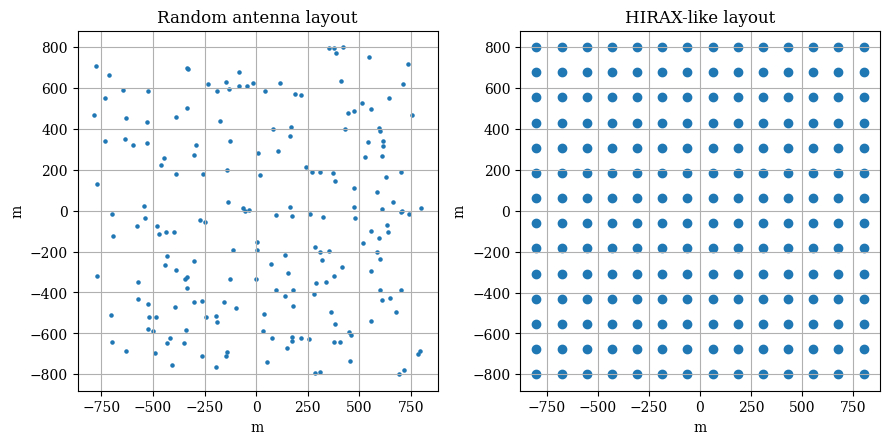

In [16]:
FoV= 4.*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 128).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
#Generate the coordinates of the telescope layout
xyz_grid= hirax_layout(14**2, [-800., 800.])
xyz_random= random_layout(14**2, [-800., 800.], 2024)
#***********************************************

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
ang_dim_dist= FoV.to('rad').value * cosmo.angular_diameter_distance(rshift).value

#Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=ang_dim_dist, rseed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord)

#***********************************************
fig, axes= plt.subplots(1, 2, figsize=(9, 7))

axes[0].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[0].set_xlabel("m")
axes[0].set_ylabel("m")
axes[0].set_title("Random antenna layout")
axes[0].grid()
axes[0].set_box_aspect(1)

axes[1].scatter(xyz_grid[:,0], xyz_grid[:, 1])
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("HIRAX-like layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()

In [17]:
visls_grid_synchro, vismx_grid_synchro, bl_grid_synchro= visibility_matrix_func_new_method(xyz_grid, thet, rshift, synchro_source, np.ones(l_coord.shape))
visls_grid_gaussian, vismx_grid_gaussian, bl_grid_gaussian= visibility_matrix_func_new_method(xyz_grid, thet, rshift, gaussian_source, np.ones(l_coord.shape))

visls_random_synhro, vismx_random_synchro, bl_random_synchro= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, np.ones(l_coord.shape))
visls_random_gaussian, vismx_random_gaussian, bl_random_gaussian= visibility_matrix_func_new_method(xyz_random, thet, rshift, gaussian_source, np.ones(l_coord.shape))

visls_grid_uniform, vismx_grid_uniform, bl_grid_uniform= visibility_matrix_func_new_method(xyz_grid, thet, rshift, np.ones(l_coord.shape), np.ones(l_coord.shape))
visls_random_uniform, vismx_random_uniform, bl_random_uniform= visibility_matrix_func_new_method(xyz_random, thet, rshift, np.ones(l_coord.shape), np.ones(l_coord.shape))

#Defning a delta source at the center of the grid
delta_source= np.zeros((len(thet), len(thet)))
delta_source[63,63]= 30000
visls_grid_delta, vismx_grid_delta, bl_grid_delta= visibility_matrix_func_new_method(xyz_grid, thet, rshift, delta_source, np.ones(l_coord.shape))
visls_random_delta, vismx_random_delta, bl_random_delta= visibility_matrix_func_new_method(xyz_random, thet, rshift, delta_source, np.ones(l_coord.shape))

100%|██████████| 19110/19110 [00:28<00:00, 663.14it/s]


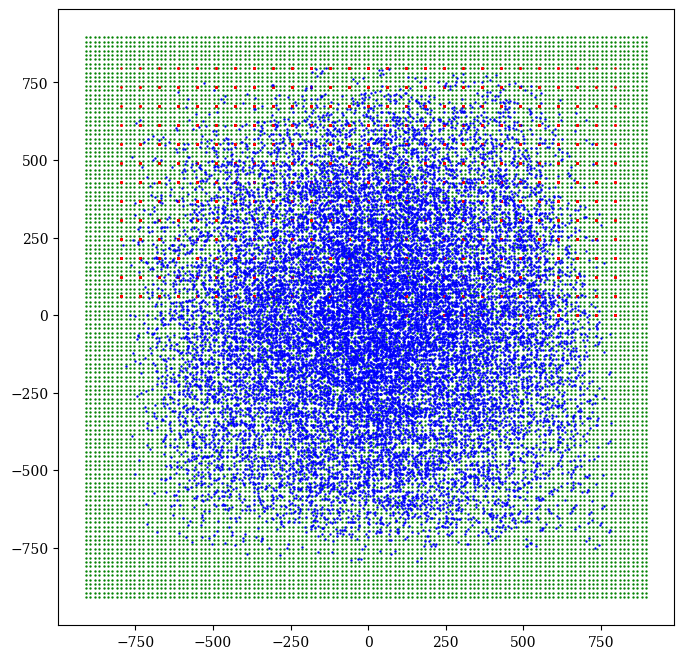

In [18]:
# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

fig, axes= plt.subplots(1, 1, figsize=(8, 8))
axes.scatter(u_freq, v_freq, color='green', s=0.5)
axes.scatter(bl_grid_synchro[:, 0], bl_grid_synchro[:, 1], color='red', s=0.5, label="Grid layout")
axes.scatter(bl_random_synchro[:, 0], bl_random_synchro[:, 1], color='blue', s=0.5, label="Random layout")
axes.set_box_aspect(1)

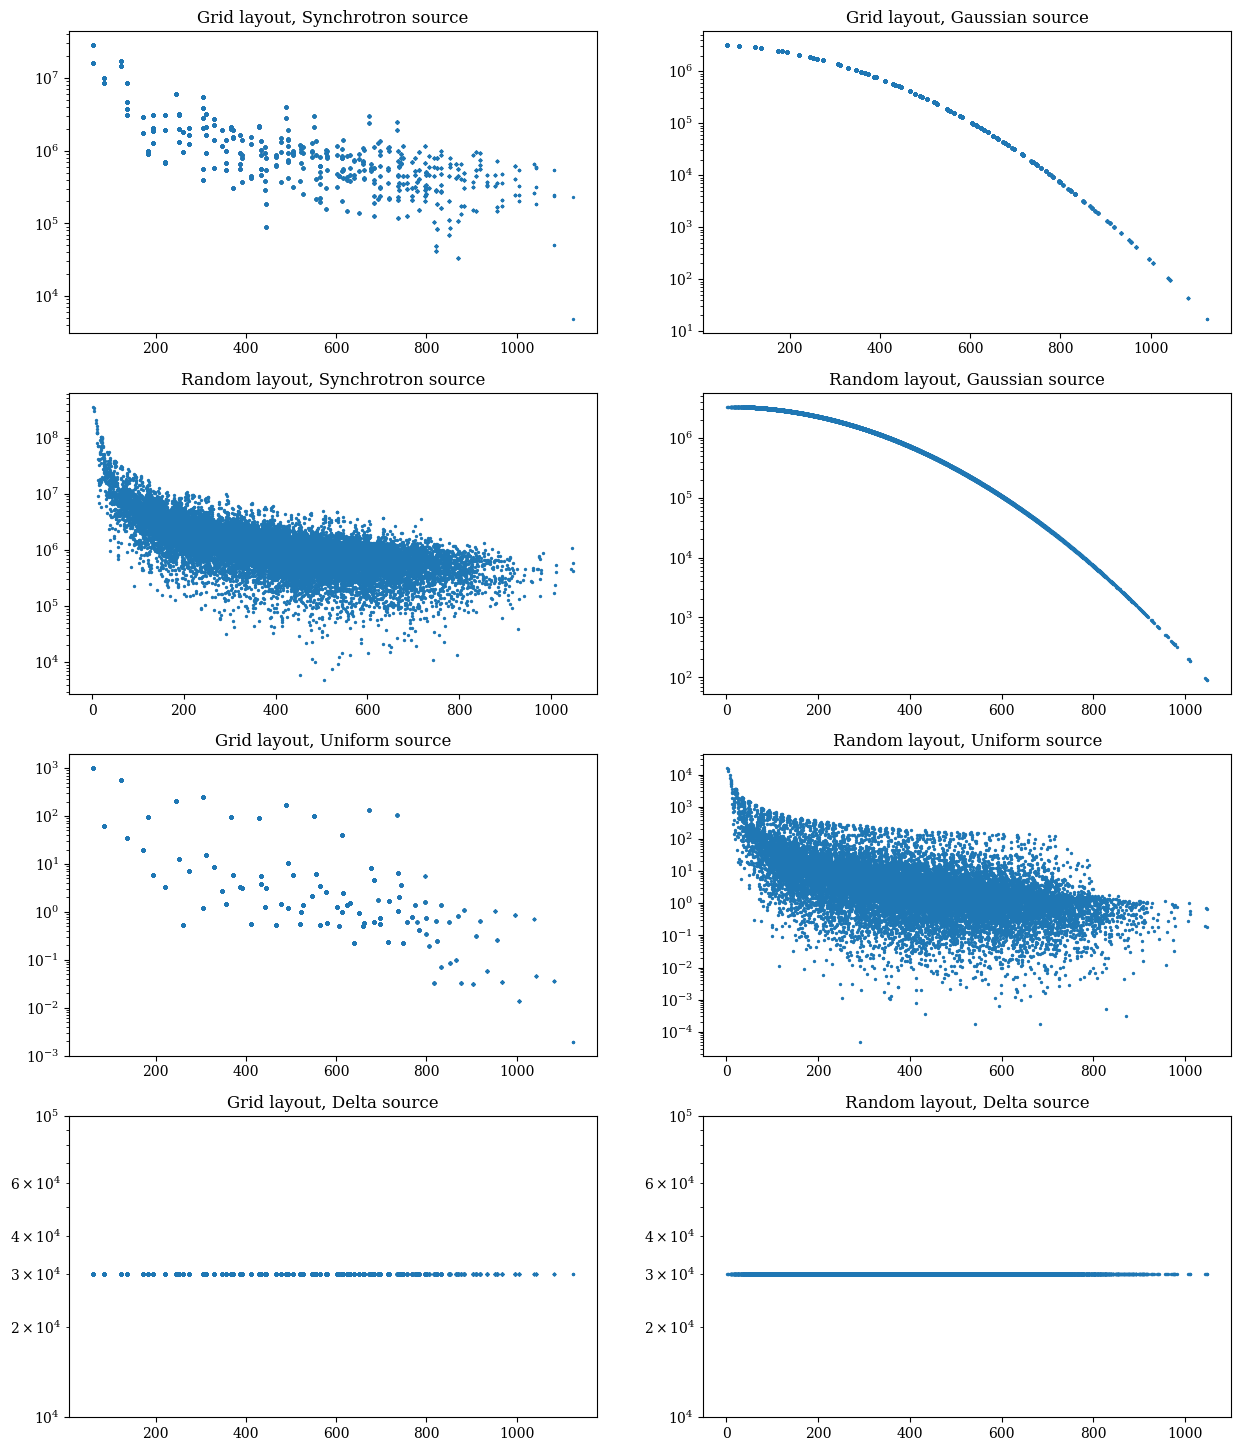

In [19]:
fig, axes= plt.subplots(4, 2, figsize=(15, 18))

axes[0,0].scatter(np.linalg.norm(bl_grid_synchro, axis=1), np.abs(visls_grid_synchro), s=2)
axes[0,0].set_title("Grid layout, Synchrotron source")
axes[0,0].set_yscale('log')

axes[0,1].scatter(np.linalg.norm(bl_grid_gaussian, axis=1), np.abs(visls_grid_gaussian), s=2)
axes[0,1].set_title("Grid layout, Gaussian source")
axes[0,1].set_yscale('log')

axes[1,0].scatter(np.linalg.norm(bl_random_synchro, axis=1), np.abs(visls_random_synhro), s=2)
axes[1,0].set_title("Random layout, Synchrotron source")
axes[1,0].set_yscale('log')

axes[1,1].scatter(np.linalg.norm(bl_random_gaussian, axis=1), np.abs(visls_random_gaussian), s=2)
axes[1,1].set_title("Random layout, Gaussian source")
axes[1,1].set_yscale('log')

axes[2,0].scatter(np.linalg.norm(bl_grid_uniform, axis=1), np.abs(visls_grid_uniform), s=2)
axes[2,0].set_title("Grid layout, Uniform source")
axes[2,0].set_yscale('log')

axes[2,1].scatter(np.linalg.norm(bl_random_uniform, axis=1), np.abs(visls_random_uniform), s=2)
axes[2,1].set_title("Random layout, Uniform source")
axes[2,1].set_yscale('log')

axes[3,0].scatter(np.linalg.norm(bl_grid_delta, axis=1), np.abs(visls_grid_delta), s=2)
axes[3,0].set_title("Grid layout, Delta source")
axes[3,0].set_yscale('log')

axes[3,1].scatter(np.linalg.norm(bl_random_delta, axis=1), np.abs(visls_random_delta), s=2)
axes[3,1].set_title("Random layout, Delta source")
axes[3,1].set_yscale('log')

## __Plotting the images recostructed from visibilities.__

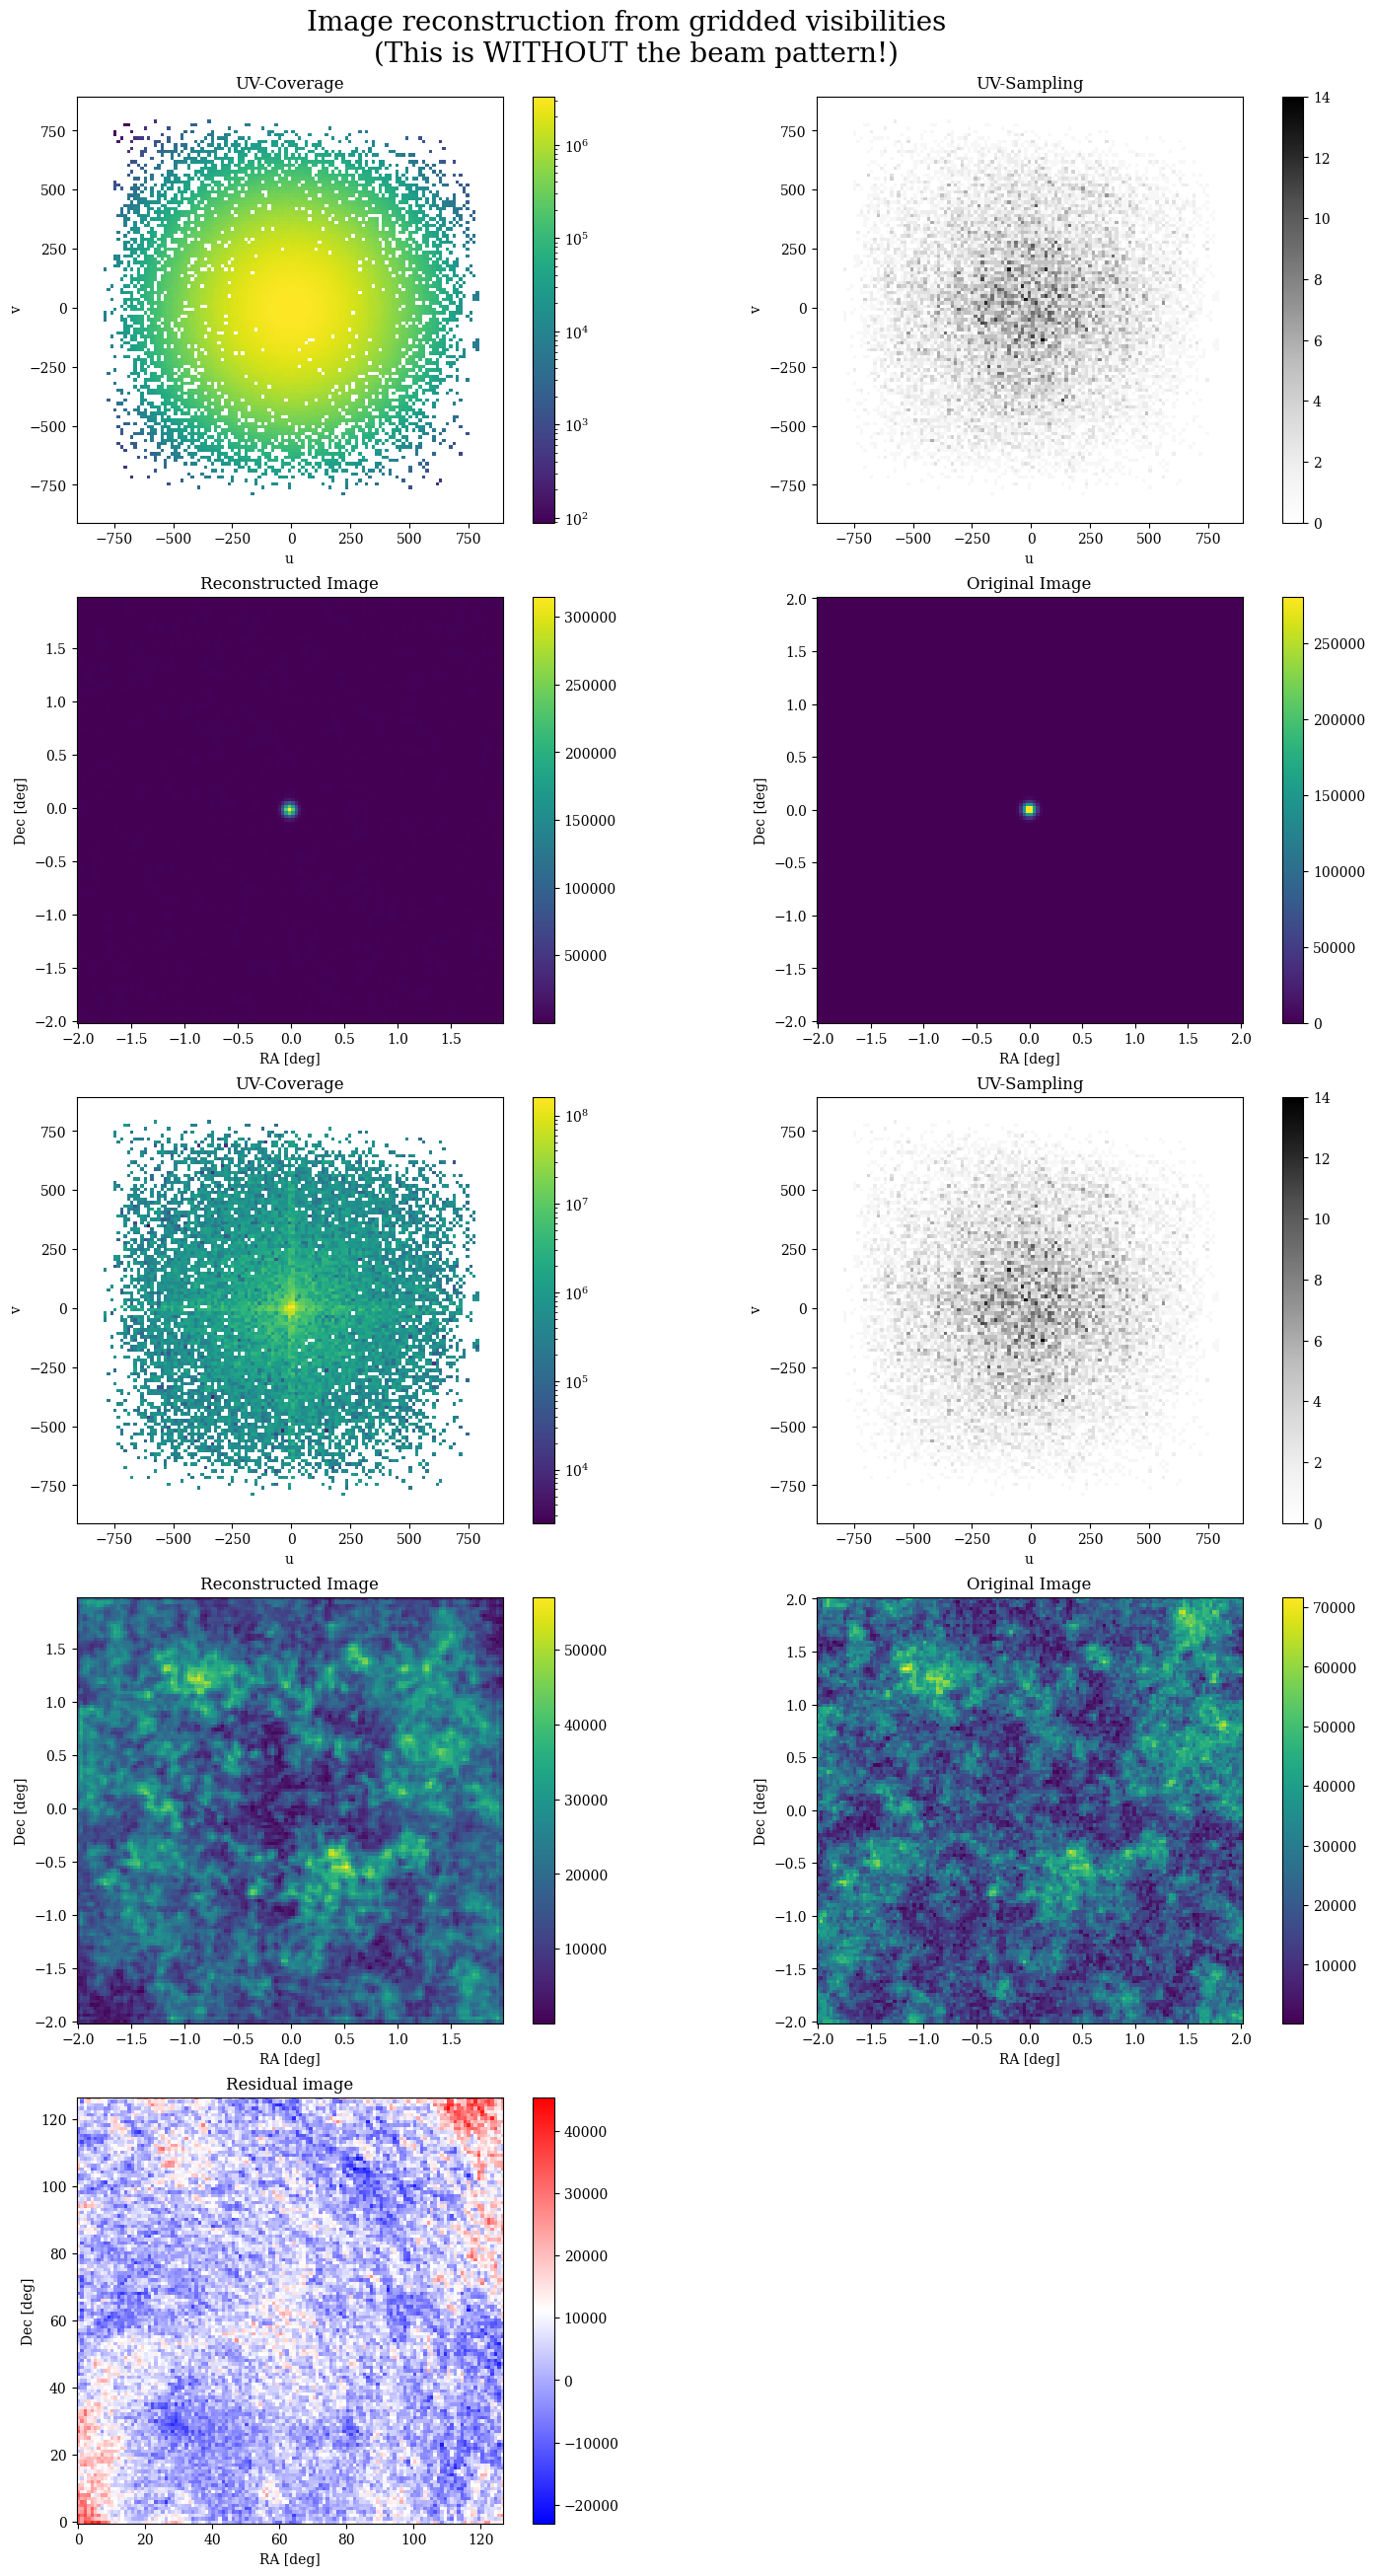

In [20]:
fig, axs= plt.subplots(figsize=(15, 26), ncols=2, nrows=5, constrained_layout=True)

fig.suptitle("Image reconstruction from gridded visibilities \n (This is WITHOUT the beam pattern!)", fontsize=20)

# Plot the reconstructed image
binned_random_gaussian, uv_bin_random_gaussian, uv_sampl_random_gaussian, x_random_gaussian= image_reconstructing_func(visls_random_gaussian, 
                                                                                                bl_random_gaussian, uu[0], uu[-1], len(uu), 1)

# Plot gridded visibilities
im0= axs[0,0].pcolormesh(uv_bin_random_gaussian, uv_bin_random_gaussian, np.abs(binned_random_gaussian), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV-Coverage')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im0, ax=axs[0,0])

im1= axs[0,1].pcolormesh(uv_bin_random_gaussian, uv_bin_random_gaussian, uv_sampl_random_gaussian, cmap='Greys')
axs[0,1].set_title('UV-Sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im1, ax=axs[0,1])

im2= axs[1,0].pcolormesh(np.rad2deg(x_random_gaussian*u.rad).value, np.rad2deg(x_random_gaussian*u.rad).value, 
                         np.fft.fftshift(np.abs(np.fft.ifft2(binned_random_gaussian))), cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im2, ax=axs[1,0])

im3= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im3, ax=axs[1,1])

#Plot another reconstructed image
binned_random_synchro, uv_bin_random_synchro, us_sampl_random_synchro, x_random_synchro= image_reconstructing_func(visls_random_synhro, 
                                                                                            bl_random_synchro, uu[0], uu[-1], len(uu), 1)

# Plot gridded visibilities
im4= axs[2,0].pcolormesh(uv_bin_random_synchro, uv_bin_random_synchro, np.abs(binned_random_synchro), norm=LogNorm(), cmap='viridis')
axs[2,0].set_title('UV-Coverage')
axs[2,0].set_xlabel('u')
axs[2,0].set_ylabel('v')
axs[2,0].set_box_aspect(1)
plt.colorbar(im4, ax=axs[2,0])

im5= axs[2,1].pcolormesh(uv_bin_random_synchro, uv_bin_random_synchro, us_sampl_random_synchro, cmap='Greys')
axs[2,1].set_title('UV-Sampling')
axs[2,1].set_xlabel('u')
axs[2,1].set_ylabel('v')
axs[2,1].set_box_aspect(1)
plt.colorbar(im5, ax=axs[2,1])

synchro_reconstructed_rotflip= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(binned_random_synchro))), k=-1), axis=1)
im6= axs[3,0].pcolormesh(np.rad2deg(x_random_synchro*u.rad).value, np.rad2deg(x_random_synchro*u.rad).value,
                        synchro_reconstructed_rotflip, cmap='viridis')
axs[3,0].set_title('Reconstructed Image')
axs[3,0].set_xlabel('RA [deg]')
axs[3,0].set_ylabel('Dec [deg]')
axs[3,0].set_box_aspect(1)
plt.colorbar(im6, ax=axs[3,0])

im7= axs[3,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source, cmap='viridis')
axs[3,1].set_title('Original Image')
axs[3,1].set_xlabel('RA [deg]')
axs[3,1].set_ylabel('Dec [deg]')
axs[3,1].set_box_aspect(1)
plt.colorbar(im7, ax=axs[3,1])

im8= axs[4,0].imshow(synchro_source[:-1, :-1] - synchro_reconstructed_rotflip, cmap='bwr', origin='lower')
axs[4,0].set_title('Residual image')
axs[4,0].set_xlabel('RA [deg]')
axs[4,0].set_ylabel('Dec [deg]')
axs[4,0].set_box_aspect(1)
plt.colorbar(im8, ax=axs[4,0])

fig.delaxes(axs[4, 1])

100%|██████████| 19110/19110 [00:52<00:00, 364.54it/s]


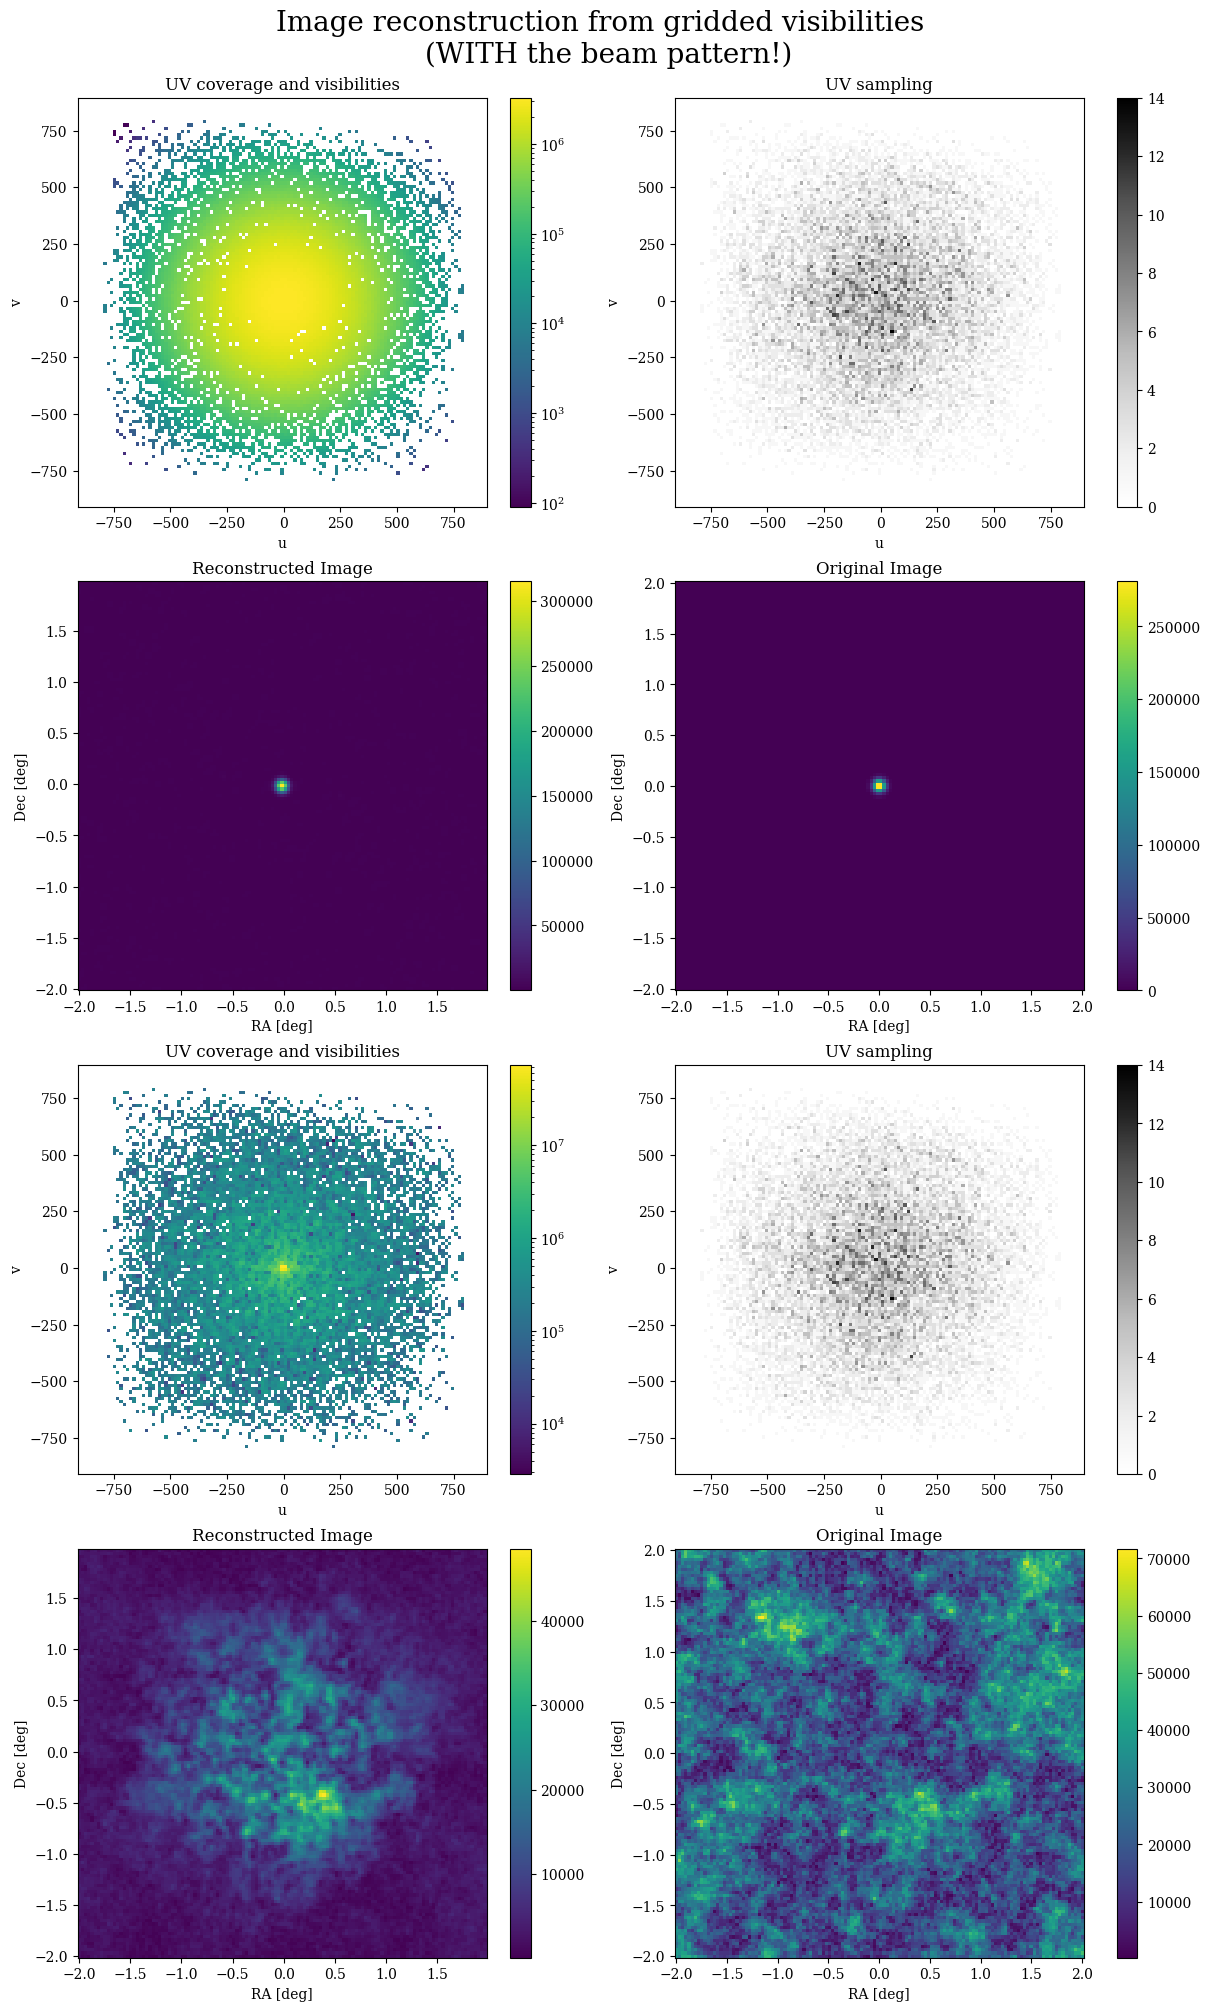

In [21]:
fig, axs= plt.subplots(figsize=(12, 20), ncols=2, nrows=4, constrained_layout=True)

fig.suptitle("Image reconstruction from gridded visibilities \n (WITH the beam pattern!)", fontsize=20)

visls_random_gaussian, vismx_random_gaussian, bl_random_gaussian= visibility_matrix_func_new_method(xyz_random, thet, rshift, gaussian_source, beam_pattern)
bin_random_gaussian, uvbin_random_gaussian, uvsampl_random_gaussian, x_random_gaussian= image_reconstructing_func(visls_random_gaussian, bl_random_gaussian, uu[0], uu[-1], len(uu), 1)

im00= axs[0,0].pcolormesh(uvbin_random_gaussian, uvbin_random_gaussian, np.abs(bin_random_gaussian), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV coverage and visibilities')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im00, ax=axs[0,0])

im01= axs[0,1].pcolormesh(uvbin_random_gaussian, uvbin_random_gaussian, uvsampl_random_gaussian, cmap='Greys')
axs[0,1].set_title('UV sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im01, ax=axs[0,1])

img_random_gaussian_rotflip= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(bin_random_gaussian))), k=-1), axis=1)
im10= axs[1,0].pcolormesh(np.rad2deg(x_random_gaussian*u.rad).value, np.rad2deg(x_random_gaussian*u.rad).value, img_random_gaussian_rotflip, cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im10, ax=axs[1,0])

im11= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im11, ax=axs[1,1])


visls_random_synchro, vismx_random_synchro, bl_random_synchro= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, beam_pattern)
bin_random_synchro, uvbin_random_synchro, uvsampl_random_synchro, x_random_synchro= image_reconstructing_func(visls_random_synchro, bl_random_synchro, uu[0], uu[-1], len(uu), 1)

im20= axs[2,0].pcolormesh(uvbin_random_synchro, uvbin_random_synchro, np.abs(bin_random_synchro), norm=LogNorm(), cmap='viridis')
axs[2,0].set_title('UV coverage and visibilities')
axs[2,0].set_xlabel('u')
axs[2,0].set_ylabel('v')
axs[2,0].set_box_aspect(1)
plt.colorbar(im20, ax=axs[2,0])

im21= axs[2,1].pcolormesh(uvbin_random_synchro, uvbin_random_synchro, uvsampl_random_synchro, cmap='Greys')
axs[2,1].set_title('UV sampling')
axs[2,1].set_xlabel('u')
axs[2,1].set_ylabel('v')
axs[2,1].set_box_aspect(1)
plt.colorbar(im21, ax=axs[2,1])

img_synchro_rotflip= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(bin_random_synchro))), k=-1), axis=1)
im30= axs[3,0].pcolormesh(np.rad2deg(x_random_synchro*u.rad).value, np.rad2deg(x_random_synchro*u.rad).value, img_synchro_rotflip, cmap='viridis')
axs[3,0].set_title('Reconstructed Image')
axs[3,0].set_xlabel('RA [deg]')
axs[3,0].set_ylabel('Dec [deg]')
axs[3,0].set_box_aspect(1)
plt.colorbar(im30, ax=axs[3,0])

im31= axs[3,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source, cmap='viridis')
axs[3,1].set_title('Original Image')
axs[3,1].set_xlabel('RA [deg]')
axs[3,1].set_ylabel('Dec [deg]')
axs[3,1].set_box_aspect(1)
plt.colorbar(im31, ax=axs[3,1])